Install Library

In [ ]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 2.7 MB/s eta 0:00:00


Import Library

In [ ]:
from ultralytics import YOLO
import os
import zipfile

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


Upload Dataset zip

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Road Vehicle Images Dataset.zip to Road Vehicle Images Dataset.zip


Ekstrak Dataset

In [ ]:
zip_path = "/content/Road Vehicle Images Dataset.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/dataset")

print("Dataset berhasil diekstrak!")

Dataset berhasil diekstrak!


Cek isi Dataset

In [ ]:
os.listdir("/content/dataset")

['trafic_data']

Load Model YOLOv8

In [ ]:
model = YOLO("yolov8n.pt")

Mencari lokasi data_1.yaml

In [ ]:
import os

for root, dirs, files in os.walk("/content"):
    if "data_1.yaml" in files:
        print("Ditemukan di:", os.path.join(root, "data_1.yaml"))

Ditemukan di: /content/dataset/trafic_data/data_1.yaml


Training Model

In [ ]:
results = model.train(
    data="/content/dataset/trafic_data/data_1.yaml",
    epochs=5,
    imgsz=320,
    batch=8,
    workers=2,
    project="/content/runs",
    name="vehicle_detection"
)

Ultralytics 8.4.93 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (AMD EPYC 7B12)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/trafic_data/data_1.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=vehicle_detection, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, over

Evaluasi Model

In [ ]:
metrics = model.val()
print(metrics)

Ultralytics 8.4.93 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (AMD EPYC 7B12)
Model summary (fused): 73 layers, 3,009,743 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1303.8±224.5 MB/s, size: 36.7 KB)
val: Scanning /content/dataset/trafic_data/valid/labels.cache... 300 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 300/300 11.7Mit/s 0.0s
val: /content/dataset/trafic_data/valid/images/Pias--359-_PNG.rf.43bcf36efe5cf8c37552d2c45fffea60.jpg: 9 duplicate labels removed
val: /content/dataset/trafic_data/valid/images/Pias--360-_PNG.rf.8405b0e44009a9300e0a1100ccf7d5b3.jpg: 7 duplicate labels removed
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 19/19 1.4it/s 13.3s
                   all        300       2568      0.516      0.182      0.166     0.0954
               bicycle         30         32          0          0    0.00426   0.000989
                   bus        220        425       0.

Upload Gambar Uji

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving jalan.jpg to jalan (1).jpg


Cek Lokasi best

In [ ]:
!find /content/runs -name "best.pt"

/content/runs/vehicle_detection/weights/best.pt


Download best

In [ ]:
from google.colab import files

files.download("/content/runs/vehicle_detection/weights/best.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Prediksi

In [ ]:
best_model = YOLO("/content/runs/vehicle_detection/weights/best.pt")

results = best_model.predict(
    source="/content/jalan.jpg",
    conf=0.25,
    save=True
)


image 1/1 /content/jalan.jpg: 192x320 33 cars, 1 three wheelers -CNG-, 42.0ms
Speed: 1.4ms preprocess, 42.0ms inference, 1.9ms postprocess per image at shape (1, 3, 192, 320)
Results saved to /content/runs/detect/predict


Tampilkan Hasil

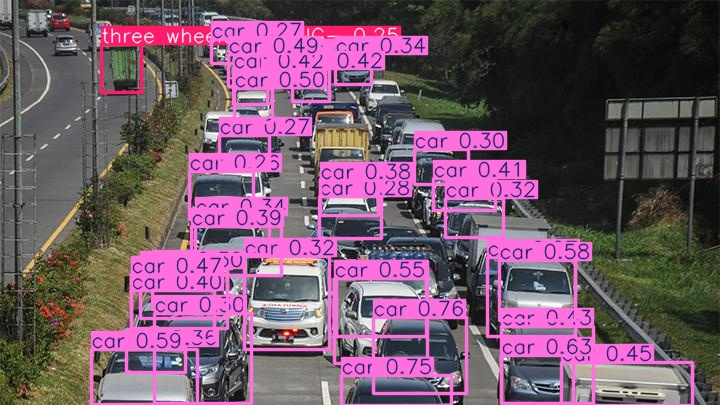

In [ ]:
from IPython.display import Image, display

display(Image("/content/runs/detect/predict/jalan.jpg"))

Download Hasil Gambar

In [ ]:
from google.colab import files

files.download("/content/runs/detect/predict/jalan.jpg")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>